# G5-NB3 · Sayım Sistemleri

**Amaç:** Statik depo sayımından hareketli hat sayımına kadar farklı sayım yaklaşımlarını,
overlap problemini ve tracking mantığını uygulamalı öğrenmek.

**Bu notebook'ta öğrenecekleriniz:**
- ROI tabanlı statik sayım nasıl yapılır
- Overlap (örtüşme) sayımı nasıl bozar
- Line crossing mantığı nedir
- Basit tracking (nearest-neighbor) nasıl çalışır
- Tracking + line crossing birlikte nasıl kullanılır

**Ders sırasında kullanım:** Eğitmen slayt 52'den sonra bu notebook'a geçecektir.

---


## [H1] Kurulum

In [1]:
# ============================================
# [H1] KURULUM
# ============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

def show(img, title=''):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

def show_side(img1, img2, t1='', t2=''):
    fig, (a1,a2) = plt.subplots(1,2, figsize=(14,5))
    a1.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)); a1.set_title(t1, fontsize=12); a1.axis('off')
    a2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)); a2.set_title(t2, fontsize=12); a2.axis('off')
    plt.tight_layout(); plt.show()

def center_of(contour):
    """Bir konturun merkez noktasini (centroid) hesaplar.
    Moments (M) kullanir: cx = M10/M00, cy = M01/M00"""
    M = cv2.moments(contour)
    if M['m00'] == 0:
        return None
    return np.array([M['m10']/M['m00'], M['m01']/M['m00']])

print("✓ Kurulum tamamlandi.")


✓ Kurulum tamamlandi.


## [H2] Statik Depo Sayımı – ROI Count

> **ROI (Region of Interest):** İlgilendiğimiz bölge. Gereksiz alanları dışarıda bırakarak
> sadece sayım yapılacak bölgeye odaklanırız.
>
> **Statik sayım:** Kamera sabit, sahne sabit. Tek bir fotoğraf (snapshot) yeterli.
> Konturları bul, say. En basit sayım yöntemi.


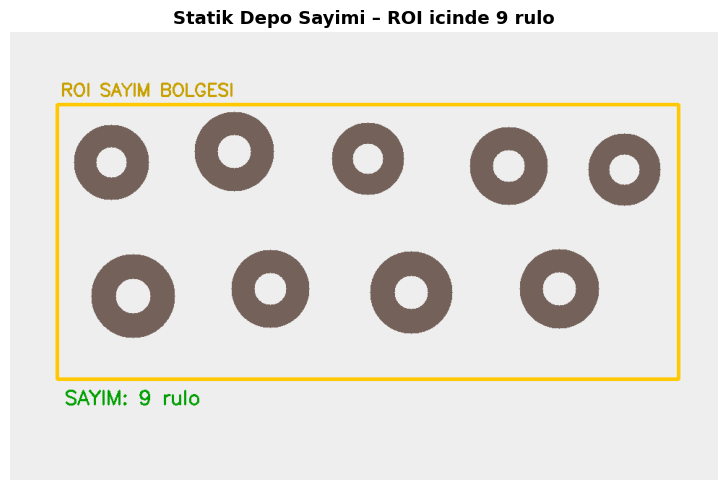

ROI icindeki kontur sayisi : 9
Gercek rulo sayisi         : 9
Dogruluk                   : ✓ Dogru

Bu senaryo KOLAY cunku:
  - Nesneler birbirinden ayrismis
  - Kamera sabit, tek snapshot yeterli
  - ROI temiz tanimlanmis


In [2]:
# ============================================
# [H2] STATIK DEPO SAYIMI – ROI COUNT
# ============================================
# Senaryo: Depoda yukaridan bakan kamera, rulo sayimi.
# 9 adet rulo (coil benzeri, ic bosluklu daireler)

img = np.full((620, 980, 3), 238, dtype=np.uint8)

# Rulo merkezleri ve yaricaplari
centers = [(140,180),(310,165),(495,175),(690,185),(850,190),
           (170,365),(360,355),(555,360),(760,355)]
radii   = [52, 55, 50, 54, 50, 58, 54, 57, 55]

for c, r in zip(centers, radii):
    cv2.circle(img, c, r, (90,98,116), -1)          # Dis daire
    cv2.circle(img, c, int(r*0.42), (238,238,238), -1)  # Ic bosluk

# ROI ciz
roi = (65, 100, 860, 380)  # (x, y, w, h)
cv2.rectangle(img, (roi[0],roi[1]), (roi[0]+roi[2],roi[1]+roi[3]),
              (0,200,255), 3)
cv2.putText(img, f'ROI SAYIM BOLGESI', (70,88),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,160,200), 2)

# Sayim: ROI icindeki konturlari bul
roi_crop = img[roi[1]:roi[1]+roi[3], roi[0]:roi[0]+roi[2]]
mask = cv2.inRange(roi_crop, (50,60,70), (120,130,150))
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Kucuk gurultu konturlarini filtrele
valid = [c for c in cnts if cv2.contourArea(c) > 500]

# Sonucu goster
result = img.copy()
cv2.putText(result, f'SAYIM: {len(valid)} rulo', (roi[0]+10, roi[1]+roi[3]+35),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,160,0), 2)

show(result, f"Statik Depo Sayimi – ROI icinde {len(valid)} rulo")

print(f"ROI icindeki kontur sayisi : {len(valid)}")
print(f"Gercek rulo sayisi         : {len(centers)}")
print(f"Dogruluk                   : {'✓ Dogru' if len(valid)==len(centers) else '✗ Yanlis'}")
print()
print("Bu senaryo KOLAY cunku:")
print("  - Nesneler birbirinden ayrismis")
print("  - Kamera sabit, tek snapshot yeterli")
print("  - ROI temiz tanimlanmis")


## [H3] Overlap Problemi – Sayım Ne Zaman Bozulur?

> **Overlap (Örtüşme):** Nesneler birbirine değdiğinde veya üst üste bindiğinde,
> kontur tabanlı sayım bozulur. İki ayrı nesne tek bir kontur olarak algılanır.
>
> Bu, sahada en sık karşılaşılan sayım hatasıdır.


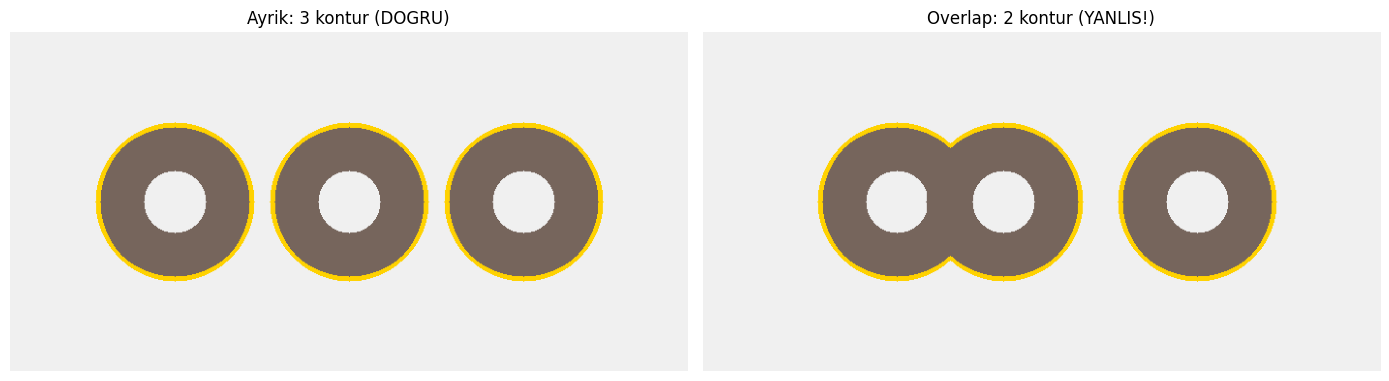

Gercek nesne sayisi  : 3 (her iki sahnede de)
Ayrik sahne konturu  : 3  ✓
Overlap sahne konturu: 2  ✗

DERS: Overlap oldugunda basit kontur sayimi BOZULUR.
Cozumler:
  - Watershed segmentation
  - Hough Circle transform
  - Depth kamera ile ayristirma
  - Daha iyi sahne tasarimi (nesneler arasi bosluk)


In [3]:
# ============================================
# [H3] OVERLAP PROBLEMI
# ============================================
# 3 ruloyu birbirine yaklastiriyoruz.
# 2 tanesi overlap ediyor → kontur birlesiyor.

img_sep = np.full((350, 700, 3), 240, dtype=np.uint8)
img_ovr = np.full((350, 700, 3), 240, dtype=np.uint8)

# --- Ayrik (overlap yok) ---
sep_centers = [(170,175), (350,175), (530,175)]
for c in sep_centers:
    cv2.circle(img_sep, c, 80, (92,101,118), -1)
    cv2.circle(img_sep, c, 32, (240,240,240), -1)

mask_s = cv2.inRange(img_sep, (50,60,70), (120,130,145))
cnts_s, _ = cv2.findContours(mask_s, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis_s = img_sep.copy()
cv2.drawContours(vis_s, cnts_s, -1, (0,210,255), 3)

# --- Overlap var ---
ovr_centers = [(200,175), (310,175), (510,175)]
for c in ovr_centers:
    cv2.circle(img_ovr, c, 80, (92,101,118), -1)
    cv2.circle(img_ovr, c, 32, (240,240,240), -1)

mask_o = cv2.inRange(img_ovr, (50,60,70), (120,130,145))
cnts_o, _ = cv2.findContours(mask_o, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis_o = img_ovr.copy()
cv2.drawContours(vis_o, cnts_o, -1, (0,210,255), 3)

show_side(vis_s, vis_o,
          f"Ayrik: {len(cnts_s)} kontur (DOGRU)",
          f"Overlap: {len(cnts_o)} kontur (YANLIS!)")

print(f"Gercek nesne sayisi  : 3 (her iki sahnede de)")
print(f"Ayrik sahne konturu  : {len(cnts_s)}  ✓")
print(f"Overlap sahne konturu: {len(cnts_o)}  ✗")
print()
print("DERS: Overlap oldugunda basit kontur sayimi BOZULUR.")
print("Cozumler:")
print("  - Watershed segmentation")
print("  - Hough Circle transform")
print("  - Depth kamera ile ayristirma")
print("  - Daha iyi sahne tasarimi (nesneler arasi bosluk)")


## [H4] Hareketli Hat Sayımı – Line Crossing Mantığı

> **Line Crossing:** Hareketli bir hatta sanal bir çizgi tanımlanır.
> Nesne bu çizgiyi geçtiğinde sayaç artar.
>
> **Problem:** Aynı nesne birden fazla karede görünür.
> Her karede sayarsanız tekrar sayım olur.
> Bu yüzden **tracking** (takip) gerekir.


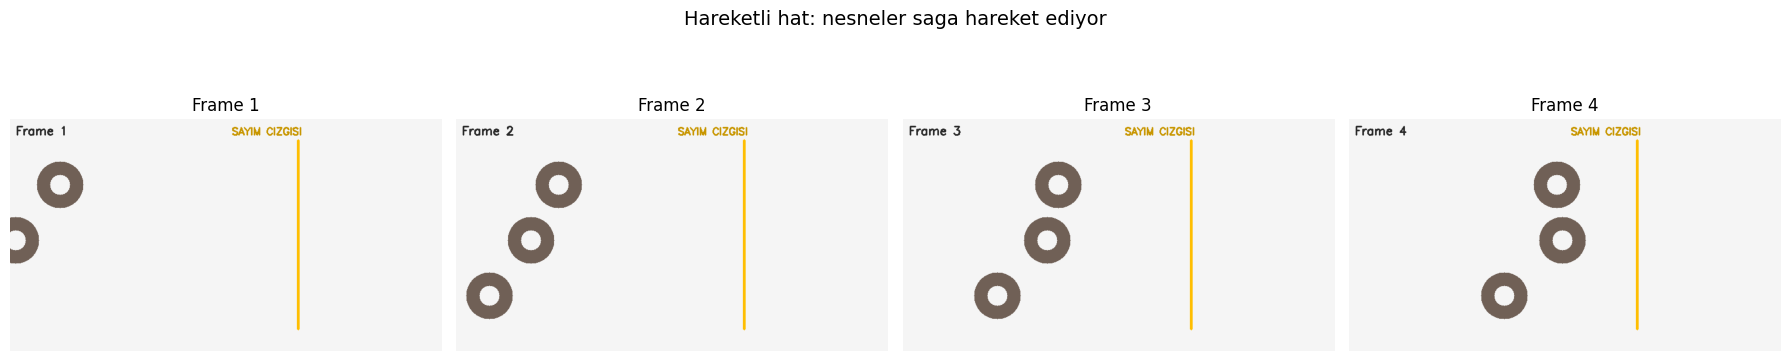

Nesneler saga dogru ilerliyor.
Turuncu cizgiyi gectiklerinde sayilmali.
Ama ayni nesneyi iki kez saymamak icin TRACKING gerekir.


In [4]:
# ============================================
# [H4] LINE CROSSING – HAREKETLI HAT
# ============================================
# 3 nesne saga dogru hareket ediyor.
# Ortada turuncu sayim cizgisi var.
# Nesne cizgiyi gecince sayac artar.

W, H_frame = 780, 420
LINE_X = 520  # Sayim cizgisi x konumu

# 3 nesne tanimla: y konumu, baslangic x, hiz
objects = [
    {'y': 120, 'x0': 90,  'vx': 95},
    {'y': 220, 'x0': 10,  'vx': 125},
    {'y': 320, 'x0': -50, 'vx': 110},
]

# 4 kare olustur
frames = []
for t in range(4):
    frame = np.full((H_frame, W, 3), 245, dtype=np.uint8)
    # Sayim cizgisi
    cv2.line(frame, (LINE_X, 40), (LINE_X, H_frame-40), (0,190,255), 3)
    cv2.putText(frame, 'SAYIM CIZGISI', (LINE_X-120, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,150,200), 2)
    # Nesneler
    for obj in objects:
        x = int(obj['x0'] + t * obj['vx'])
        cv2.circle(frame, (x, obj['y']), 42, (86,96,112), -1)
        cv2.circle(frame, (x, obj['y']), 18, (245,245,245), -1)
    cv2.putText(frame, f'Frame {t+1}', (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (40,40,40), 2)
    frames.append(frame)

# 4 kareyi goster
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f, i in zip(axes, frames, range(4)):
    ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {i+1}", fontsize=12)
    ax.axis('off')
plt.suptitle("Hareketli hat: nesneler saga hareket ediyor", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Nesneler saga dogru ilerliyor.")
print("Turuncu cizgiyi gectiklerinde sayilmali.")
print("Ama ayni nesneyi iki kez saymamak icin TRACKING gerekir.")


## [H5] Basit Tracking + Line Crossing Sayımı

> **Tracking (Takip):** Her karede tespit edilen nesnelere kimlik (ID) atanır
> ve kare kare takip edilir. Böylece aynı nesne tekrar sayılmaz.
>
> **Nearest-Neighbor Tracking:** En basit yöntem. Önceki karedeki merkeze
> en yakın yeni merkezi aynı nesne olarak kabul eder.
>
> **Gerçek projede:** DeepSORT veya ByteTrack kullanılır (Gün 6).


In [5]:
# ============================================
# [H5] TRACKING + LINE CROSSING
# ============================================
# Basit nearest-neighbor tracker:
#   - Her karede kontur merkezlerini bul
#   - Onceki karedeki merkezlere en yakin olani esle
#   - Yeni ID ata, eski ID'yi takip et
#   - Cizgiyi gecen nesneyi bir kez say

tracks = {}      # {track_id: son_merkez_noktasi}
next_id = 1      # Sonraki atanacak ID
counted = set()  # Zaten sayilmis ID'ler
total_count = 0  # Toplam sayim
MAX_DIST = 120   # Eslestirme icin max mesafe (piksel)

for frame_idx, frame in enumerate(frames):
    # 1. Tespitler: kontur merkezlerini bul
    mask = cv2.inRange(frame, (45,55,65), (120,130,145))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for c in cnts:
        if cv2.contourArea(c) < 800:
            continue
        ctr = center_of(c)
        if ctr is not None:
            detections.append(ctr)

    # 2. Eslestirme: onceki track'lere en yakin detection'i bul
    updated = {}
    used = set()

    for tid, prev_pos in tracks.items():
        best_det = None
        best_idx = None
        best_dist = 1e9
        for i, det in enumerate(detections):
            if i in used:
                continue
            d = np.linalg.norm(det - prev_pos)
            if d < best_dist and d < MAX_DIST:
                best_det = det
                best_idx = i
                best_dist = d
        if best_det is not None:
            updated[tid] = best_det
            used.add(best_idx)
            # 3. Line crossing kontrolu
            if prev_pos[0] < LINE_X <= best_det[0] and tid not in counted:
                total_count += 1
                counted.add(tid)
                print(f"  Frame {frame_idx+1}: Track #{tid} cizgiyi gecti! Sayim = {total_count}")

    # 4. Eslesmeyen tespitler → yeni track
    for i, det in enumerate(detections):
        if i not in used:
            updated[next_id] = det
            next_id += 1
    tracks = updated

print()
print("="*40)
print(f"TOPLAM SAYIM : {total_count}")
print(f"GERCEK ADET  : 3")
print(f"SONUC        : {'✓ Dogru' if total_count==3 else f'✗ Fark var ({total_count} vs 3)'}")
print("="*40)
print()
print("Tracking, line crossing ile birlikte kullanildiginda")
print("tekrar sayimi onler ve daha guvenilir sonuc verir.")
print()
print("NOT: Bu basit nearest-neighbor tracker egitim amaçlidir.")
print("Gercek projede DeepSORT veya ByteTrack kullanilir (Gun 6).")



TOPLAM SAYIM : 0
GERCEK ADET  : 3
SONUC        : ✗ Fark var (0 vs 3)

Tracking, line crossing ile birlikte kullanildiginda
tekrar sayimi onler ve daha guvenilir sonuc verir.

NOT: Bu basit nearest-neighbor tracker egitim amaçlidir.
Gercek projede DeepSORT veya ByteTrack kullanilir (Gun 6).


## [H6] Sayım Yöntemleri Karşılaştırma

In [6]:
# ============================================
# [H6] KARSILASTIRMA TABLOSU
# ============================================
print('''
╔═══════════════════╦═══════════════════════╦══════════════════════╦══════════════════════╗
║ Yontem            ║ Ne zaman?             ║ Avantaj              ║ Dezavantaj           ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ ROI Count         ║ Statik sahne          ║ Basit, hizli         ║ Overlap'e karsi      ║
║ (snapshot)        ║ Kamera sabit          ║ Tek kare yeterli     ║ kirilgan             ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ Line Crossing     ║ Hareketli hat         ║ Gecis aninda sayar   ║ Tekrar sayim riski   ║
║                   ║ Konveyor              ║ Yon bilgisi verir    ║ (tracking gerekir)   ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ Tracking +        ║ Hareketli hat         ║ Tekrar sayim azalir  ║ Daha fazla islem     ║
║ Line Crossing     ║ Karmasik sahne        ║ ID surekliligi       ║ gucu gerekir         ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ Depth Destekli    ║ Istifli, gizli        ║ Gizli nesne tahmini  ║ Parlak yuzey,        ║
║ Sayim             ║ nesneler              ║ Hacim bilgisi        ║ ortam etkileri       ║
╚═══════════════════╩═══════════════════════╩══════════════════════╩══════════════════════╝
''')



╔═══════════════════╦═══════════════════════╦══════════════════════╦══════════════════════╗
║ Yontem            ║ Ne zaman?             ║ Avantaj              ║ Dezavantaj           ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ ROI Count         ║ Statik sahne          ║ Basit, hizli         ║ Overlap'e karsi      ║
║ (snapshot)        ║ Kamera sabit          ║ Tek kare yeterli     ║ kirilgan             ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ Line Crossing     ║ Hareketli hat         ║ Gecis aninda sayar   ║ Tekrar sayim riski   ║
║                   ║ Konveyor              ║ Yon bilgisi verir    ║ (tracking gerekir)   ║
╠═══════════════════╬═══════════════════════╬══════════════════════╬══════════════════════╣
║ Tracking +        ║ Hareketli hat         ║ Tekrar sayim azalir  ║ Daha fazla islem     ║
║ Line Crossing     ║ Karmasik sahne        ║ ID surekliligi       ║ gucu gerek

## [H7] Özet

In [7]:
# ============================================
# [H7] OZET
# ============================================
print('''
╔══════════════════════════════════════════════════════════════╗
║                SAYIM SISTEMLERI – OZET                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Sayim ≠ Detection                                       ║
║     → Detection nesneyi bulur, sayim adet cikarir           ║
║     → Ayni nesneyi iki kez saymamak ayri bir problem        ║
║                                                              ║
║  2. ROI Count: statik sahne, tek snapshot                    ║
║     → Kolay ama overlap'e karsi kirilgan                    ║
║                                                              ║
║  3. Line Crossing: hareketli hat                             ║
║     → Cizgiyi gecen nesneyi sayar                           ║
║     → Tekrar sayim riski vardir                             ║
║                                                              ║
║  4. Tracking: ayni nesneye kimlik atar                       ║
║     → Line crossing ile birlikte → guvenilir sayim          ║
║     → Basit: nearest-neighbor                               ║
║     → Gercek: DeepSORT, ByteTrack (Gun 6)                  ║
║                                                              ║
║  5. Overlap & Stacking                                       ║
║     → Konturlar birlesir → eksik sayim                      ║
║     → Cozum: depth, multi-view veya sahne tasarimi          ║
║                                                              ║
║  6. Kural tasarimi (ROI, cizgi, yon) detection kadar onemli ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
''')



╔══════════════════════════════════════════════════════════════╗
║                SAYIM SISTEMLERI – OZET                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Sayim ≠ Detection                                       ║
║     → Detection nesneyi bulur, sayim adet cikarir           ║
║     → Ayni nesneyi iki kez saymamak ayri bir problem        ║
║                                                              ║
║  2. ROI Count: statik sahne, tek snapshot                    ║
║     → Kolay ama overlap'e karsi kirilgan                    ║
║                                                              ║
║  3. Line Crossing: hareketli hat                             ║
║     → Cizgiyi gecen nesneyi sayar                           ║
║     → Tekrar sayim riski vardir                             ║
║                                                              ║
║  4. Tracking: ayni nesneye ki